## Step 1: Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.set()

<Figure size 800x500 with 0 Axes>

## Step 2: Load Dataset

In [5]:
df = pd.read_csv("superstore_final_dataset (1).csv", encoding='latin1')

print(df.head())
print(df.columns)

   Row_ID        Order_ID  Order_Date   Ship_Date       Ship_Mode Customer_ID  \
0       1  CA-2017-152156   8/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156   8/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688   12/6/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer_Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3    Sean O Donnel   Consumer  United States  Fort Lauderdale     Florida   
4    Sean O Donnel   Consumer  United States  Fort Lauderdale     Florida   

   Postal_Code Region       Product_ID         Cat

## Step 3: Data Cleaning

In [7]:
# Remove spaces from column names
df.columns = df.columns.str.replace(" ", "_")

df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], dayfirst=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle missing values
df.dropna(inplace=True)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 9789 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row_ID         9789 non-null   int64         
 1   Order_ID       9789 non-null   object        
 2   Order_Date     9789 non-null   datetime64[ns]
 3   Ship_Date      9789 non-null   datetime64[ns]
 4   Ship_Mode      9789 non-null   object        
 5   Customer_ID    9789 non-null   object        
 6   Customer_Name  9789 non-null   object        
 7   Segment        9789 non-null   object        
 8   Country        9789 non-null   object        
 9   City           9789 non-null   object        
 10  State          9789 non-null   object        
 11  Postal_Code    9789 non-null   float64       
 12  Region         9789 non-null   object        
 13  Product_ID     9789 non-null   object        
 14  Category       9789 non-null   object        
 15  Sub_Category   9789 non-nu

## Step 4: Feature Engineering

In [8]:
# Extract time features
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Month_Year'] = df['Order_Date'].dt.to_period('M')

## STEP 5: KPI CALCULATIONS 

In [10]:
df.columns = df.columns.str.strip()

if 'Profit' in df.columns:
    total_profit = df['Profit'].sum()
    profit_margin = (total_profit / df['Sales'].sum()) * 100
    print("Profit:", total_profit)
    print("Profit Margin:", profit_margin)
else:
    print("Profit column not available")

Profit column not available


##  STEP 6: SALES TREND (Seasonality)

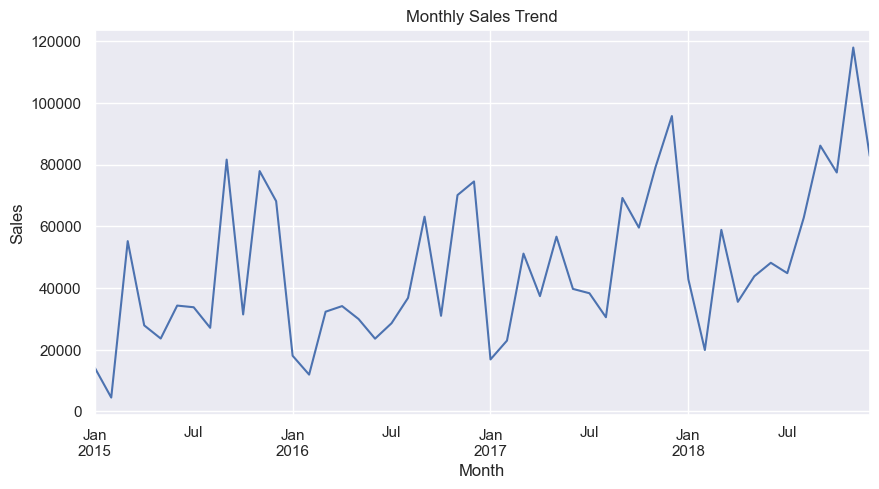

In [11]:
monthly_sales = df.groupby('Month_Year')['Sales'].sum()

monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

## STEP 7: REGION ANALYSIS

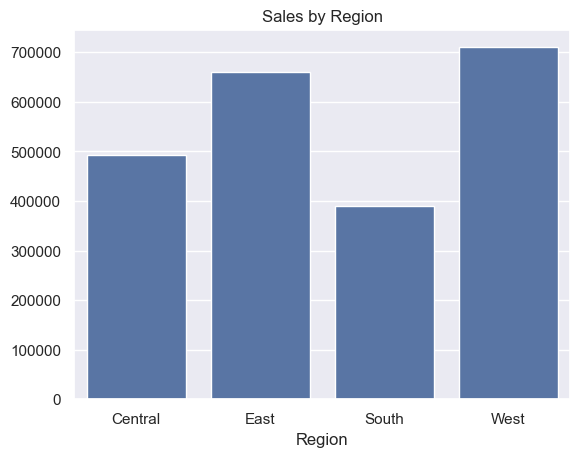

In [12]:
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure()
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title("Sales by Region")
plt.show()

## STEP 8: CATEGORY ANALYSIS

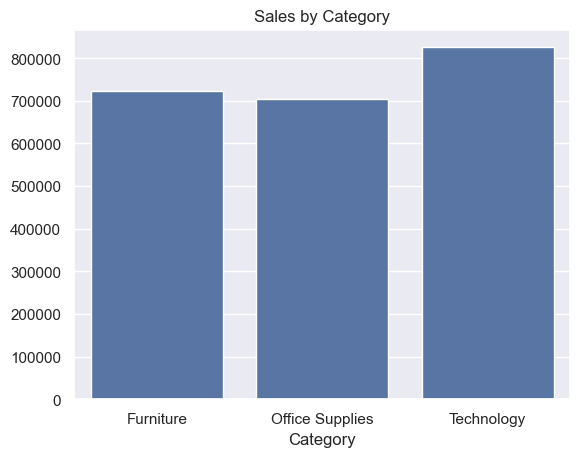

In [13]:
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure()
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title("Sales by Category")
plt.show()

## STEP 9: TOP PRODUCTS

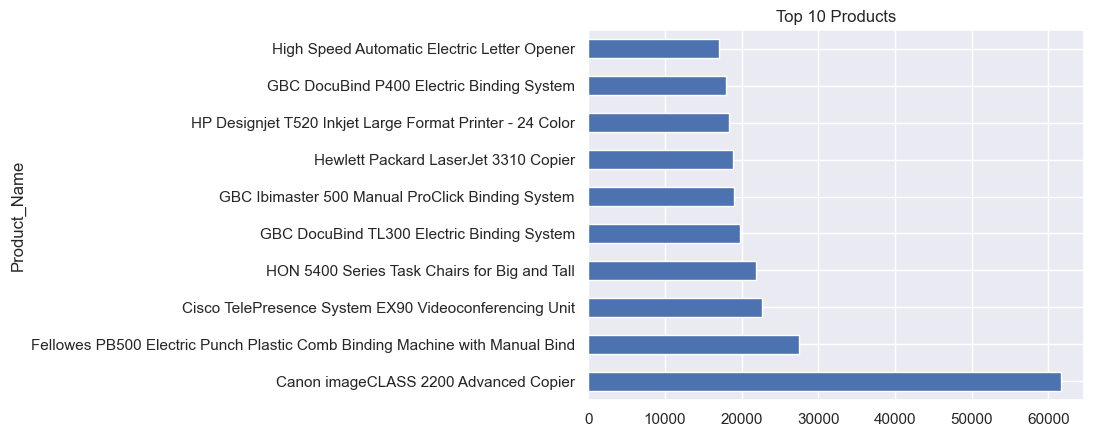

In [14]:
top_products = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_products.plot(kind='barh')
plt.title("Top 10 Products")
plt.show()

## STEP 10: WORST PRODUCTS (LOSS)

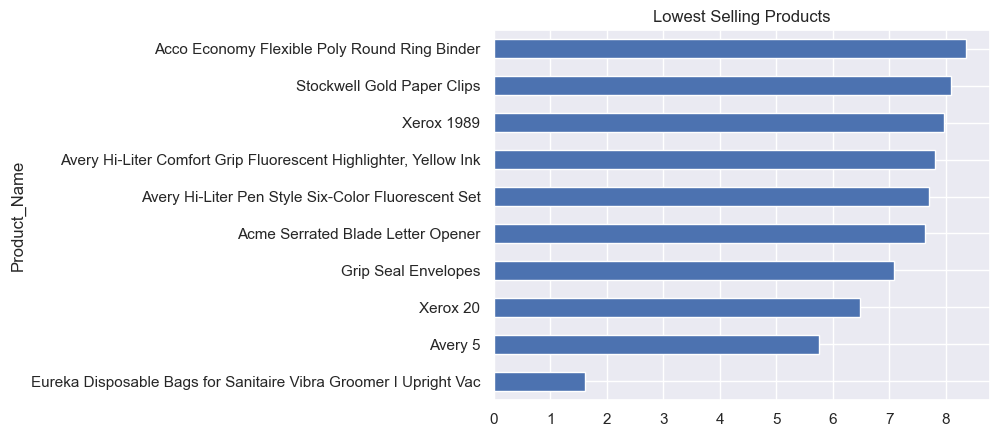

In [16]:
if 'Profit' in df.columns:
    worst_products = df.groupby('Product_Name')['Profit'].sum().sort_values().head(10)
    title = "Worst Products (Loss)"
else:
    worst_products = df.groupby('Product_Name')['Sales'].sum().sort_values().head(10)
    title = "Lowest Selling Products"

plt.figure()
worst_products.plot(kind='barh')
plt.title(title)
plt.show()

## STEP 11: DISCOUNT VS PROFIT

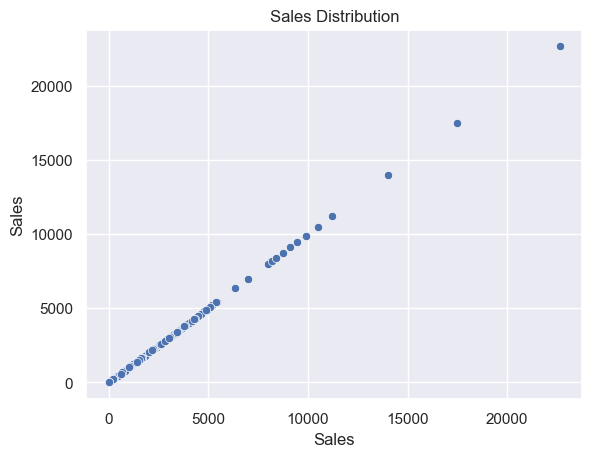

In [22]:
sns.scatterplot(x='Sales', y='Sales', data=df)
plt.title("Sales Distribution")
plt.show()

## STEP 12: SUB-CATEGORY ANALYSIS

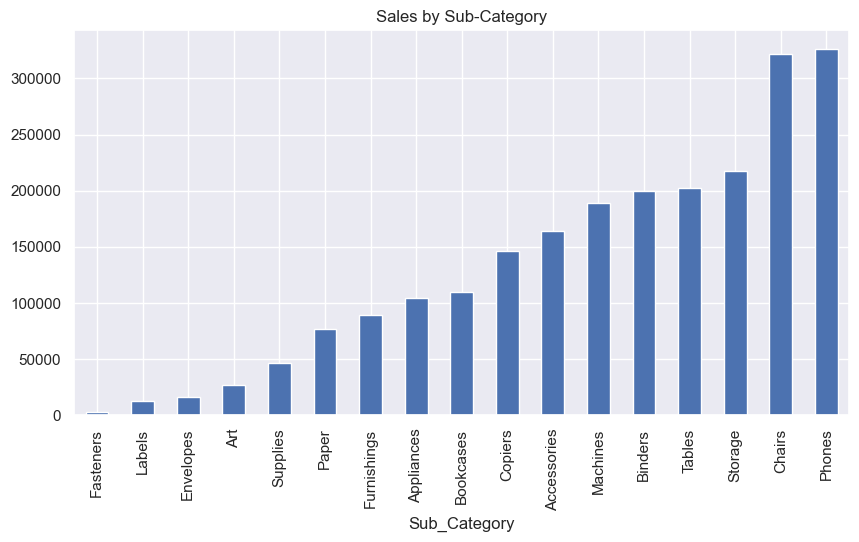

In [24]:
subcat_sales = df.groupby('Sub_Category')['Sales'].sum().sort_values()

plt.figure(figsize=(10,5))
subcat_sales.plot(kind='bar')
plt.title("Sales by Sub-Category")
plt.show()

## STEP 13: SEGMENT ANALYSIS

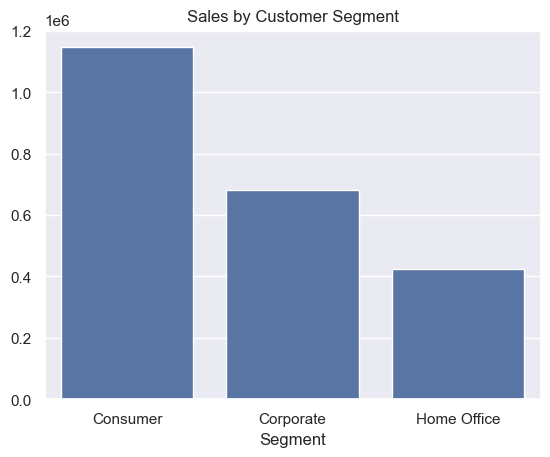

In [25]:
segment_sales = df.groupby('Segment')['Sales'].sum()

plt.figure()
sns.barplot(x=segment_sales.index, y=segment_sales.values)
plt.title("Sales by Customer Segment")
plt.show()

## STEP 14: SHIPPING ANALYSIS

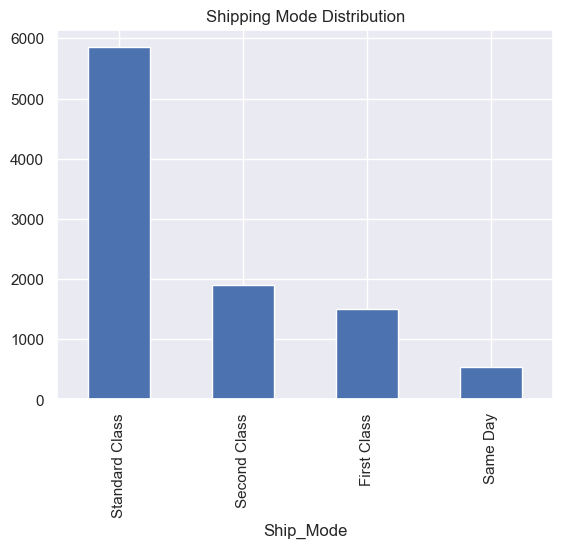

In [26]:
ship_mode = df['Ship_Mode'].value_counts()

plt.figure()
ship_mode.plot(kind='bar')
plt.title("Shipping Mode Distribution")
plt.show()

## STEP 15: SAVE OUTPUT

In [27]:
df.to_csv("cleaned_superstore_data.csv", index=False)